In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

 9. This question involves the use of multiple linear regression on the
 Auto data set.
 (a) Produce a scatterplot matrix which includes all of the variables
 in the data set.

In [7]:
AutoData=pd.read_csv("D:\ML&Fintech\data_ML&Fintech\Auto.csv")
AutoData.describe()


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Acer\AppData\Local\Temp\ipykernel_14708\2092627520.py:1: SyntaxWarning: invalid escape sequence '\M'
  AutoData=pd.read_csv("D:\ML&Fintech\data_ML&Fintech\Auto.csv")


,mpg,cylinders,displacement,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [8]:
AutoData.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

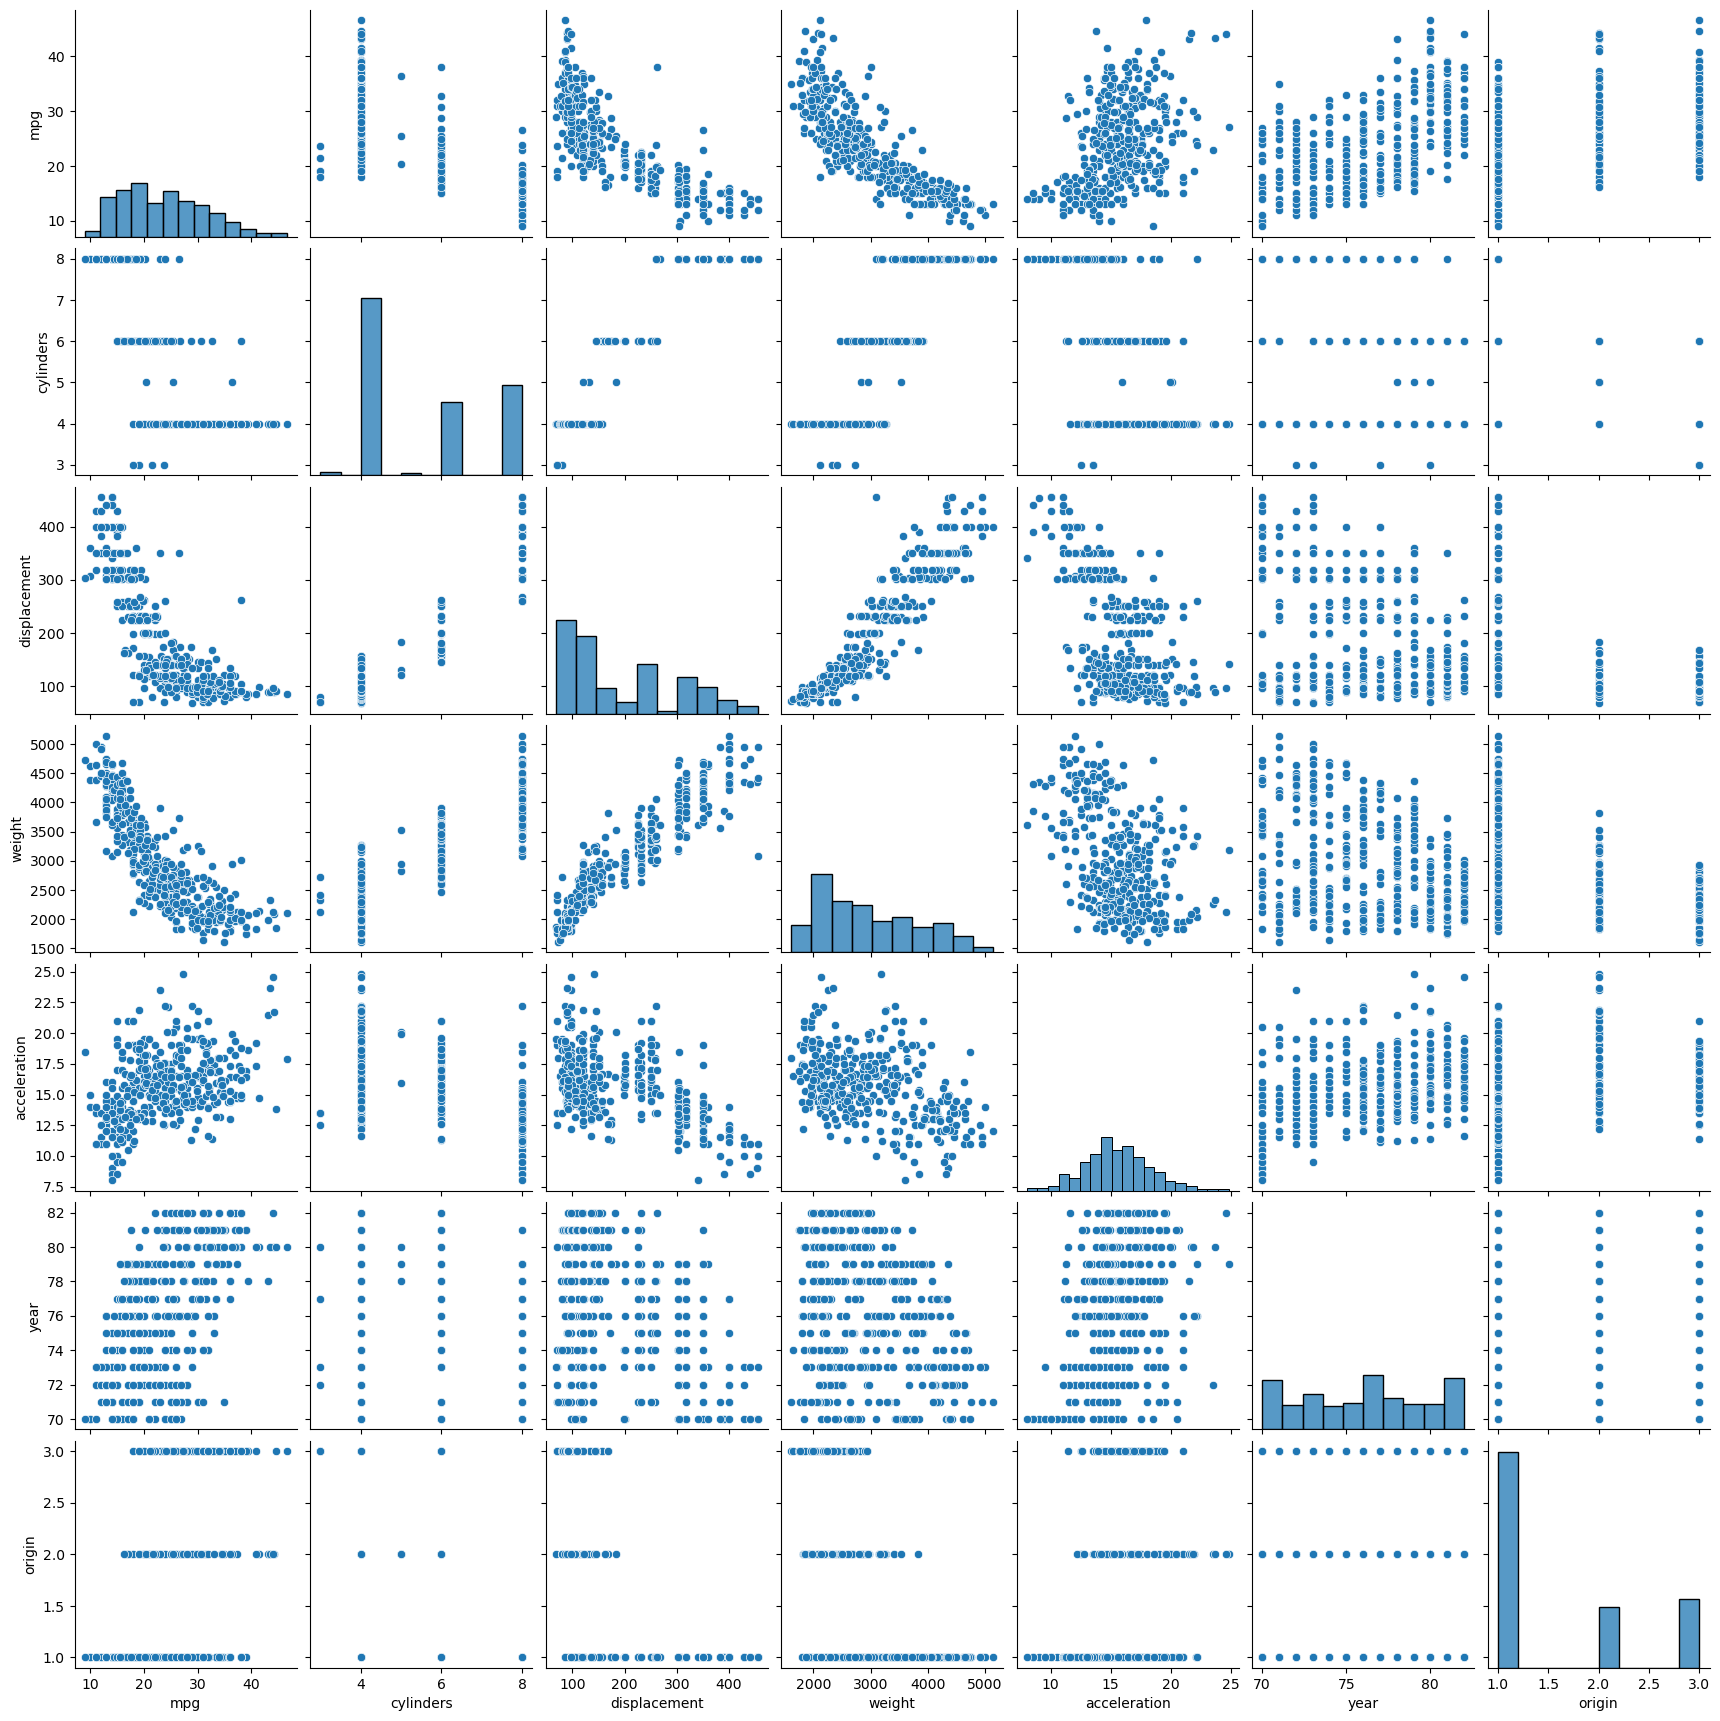

In [9]:
sns.pairplot(AutoData)

 (b) Compute the matrix of correlations between the variables using
 the DataFrame.corr() method.

In [12]:
AutoData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [15]:
AutoData.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object

In [16]:
AutoData.replace("?", np.nan, inplace=True)

In [17]:
AutoData['horsepower'] = pd.to_numeric(AutoData['horsepower'], errors='coerce')

In [18]:
AutoData.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      5
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

In [19]:
AutoData = AutoData.dropna()

In [22]:
# Remove string columns that are not numeric
Auto_numeric = AutoData.select_dtypes(include=[np.number])

# Or convert categorical columns into dummy variables
Auto_encoded = pd.get_dummies(AutoData, drop_first=True)

In [23]:
# Then compute correlation
Auto_encoded.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name_amc ambassador dpl,name_amc ambassador sst,...,name_volvo 145e (sw),name_volvo 244dl,name_volvo 245,name_volvo 264gl,name_volvo diesel,name_vw dasher (diesel),name_vw pickup,name_vw rabbit,name_vw rabbit c (diesel),name_vw rabbit custom
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209,-0.054795,-0.041819,...,-0.035332,-0.009381,-0.022356,-0.041819,0.047063,0.129457,0.133349,0.108442,0.135296,0.054848
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,0.075046,0.075046,...,-0.043695,-0.043695,-0.043695,0.015676,0.015676,-0.043695,-0.043695,-0.061873,-0.043695,-0.043695
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,0.094644,0.053029,...,-0.035524,-0.035524,-0.031169,-0.015200,-0.023910,-0.050525,-0.047137,-0.068803,-0.050525,-0.051008
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,0.112519,0.059898,...,0.009907,-0.008511,-0.003249,0.027009,-0.037453,-0.074288,-0.069026,-0.058623,-0.074288,-0.044030
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,0.052009,0.041397,...,-0.002658,-0.001942,0.010279,0.009682,0.010875,-0.038307,-0.050528,-0.079105,-0.053211,-0.062749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
name_vw dasher (diesel),0.129457,-0.043695,-0.050525,-0.074288,-0.038307,0.149746,0.055265,0.026620,-0.002558,-0.002558,...,-0.002558,-0.002558,-0.002558,-0.002558,-0.002558,1.000000,-0.002558,-0.003622,-0.002558,-0.002558
name_vw pickup,0.133349,-0.043695,-0.047137,-0.069026,-0.050528,0.166265,0.082757,0.026620,-0.002558,-0.002558,...,-0.002558,-0.002558,-0.002558,-0.002558,-0.002558,-0.002558,1.000000,-0.003622,-0.002558,-0.002558
name_vw rabbit,0.108442,-0.061873,-0.068803,-0.058623,-0.079105,-0.028364,0.039327,0.037695,-0.003622,-0.003622,...,-0.003622,-0.003622,-0.003622,-0.003622,-0.003622,-0.003622,-0.003622,1.000000,-0.003622,-0.003622
name_vw rabbit c (diesel),0.135296,-0.043695,-0.050525,-0.074288,-0.053211,0.113038,0.055265,0.026620,-0.002558,-0.002558,...,-0.002558,-0.002558,-0.002558,-0.002558,-0.002558,-0.002558,-0.002558,-0.003622,1.000000,-0.002558


(c) Use the sm.OLS() function to perform a multiple linear regression
 with mpg as the response and all other variables except name as
 the predictors. Use the summarize() function to print the results.
 Comment on the output. For instance:
 i. Is there a relationship between the predictors and the re
sponse? Use the anova_lm() function from statsmodels to
 answer this question. 
 ii. Which predictors appear to have a statistically significant
 relationship to the response?
 iii. What does the coefficient for the year variable suggest?

In [24]:
AutoData = AutoData.drop('name', axis=1)

In [25]:

x_multiple = sm.add_constant(AutoData.drop(['mpg'], axis=1))
y_multiple = AutoData['mpg']
multiple_model = sm.OLS(y_multiple, x_multiple).fit()

multiple_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        11:48:50   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

i. Except some predictors, others have relationship to the response. (p-values)
ii. `displacement`, `weight`, `year`, `origin` 
iii. One unit change in year variable results 0.7508 unit change in the response.

(d) Produce some of diagnostic plots of the linear regression fit as
 described in the lab. Comment on any problems you see with the
 f
 it. Do the residual plots suggest any unusually large outliers?
 Does the leverage plot identify any observations with unusually
 high leverage?

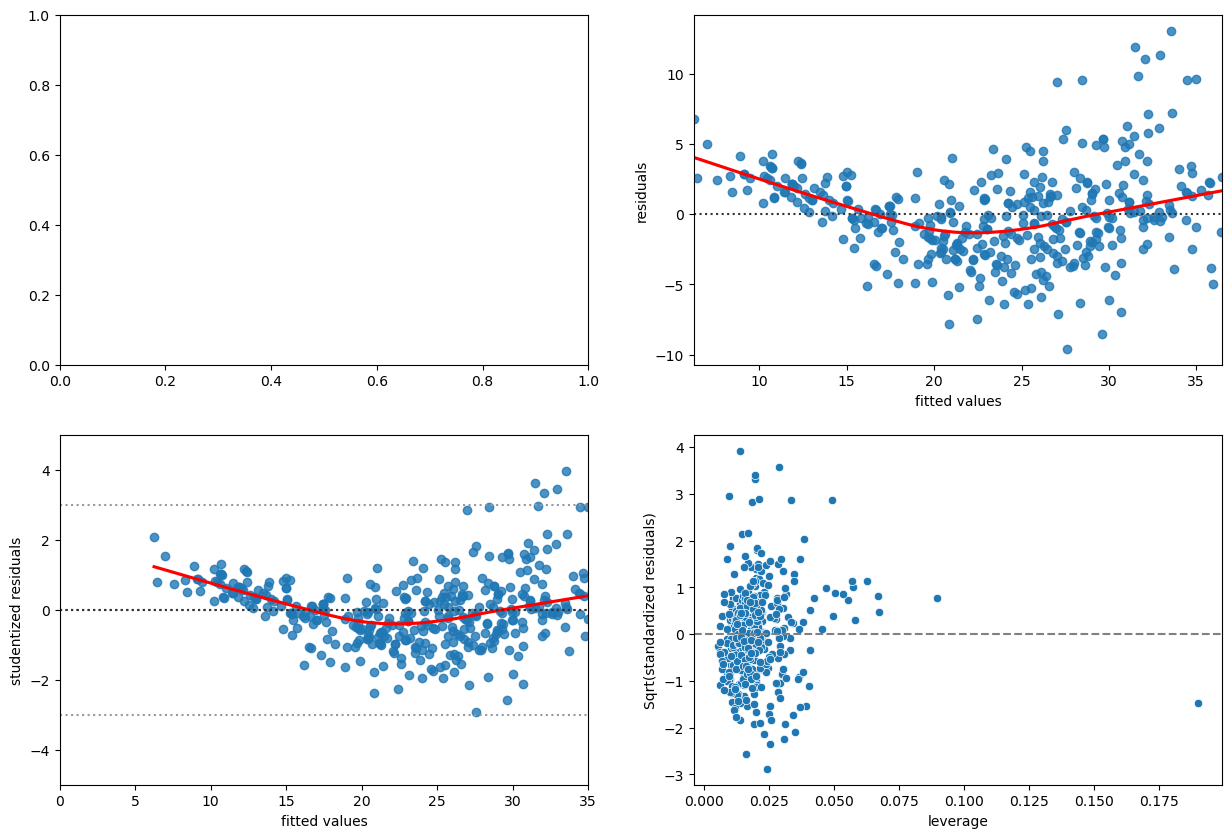

In [27]:
y_pred = multiple_model.predict(sm.add_constant(AutoData.drop(['mpg'], axis=1)))
residuals = multiple_model.resid # residual
stud_resid = multiple_model.get_influence().resid_studentized_internal # studentized residuals

f, axes = plt.subplots(2, 2, sharex=False, sharey=False)
f.set_figheight(10)
f.set_figwidth(15)

ax2 = sns.residplot(x=y_pred, y=residuals, ax=axes[0, 1], lowess=True, line_kws=dict(color="r"))
ax2.set_xlabel('fitted values')
ax2.set_ylabel('residuals')

ax2 = sns.residplot(x=y_pred, y=stud_resid, ax=axes[1, 0], lowess=True, line_kws=dict(color="r"))
ax2.set_xlabel('fitted values')
ax2.set_ylabel('studentized residuals')
ax2.axhline(0, ls=":", c=".2")
ax2.axhline(-3, ls=":", c=".6")
ax2.axhline(3, ls=":", c=".6")
ax2.set_xlim(0, 35)
ax2.set_ylim(-5, 5)

# leverage plot
stand_resids = multiple_model.resid_pearson
leverage = multiple_model.get_influence().hat_matrix_diag
ax3 = sns.scatterplot(x=leverage, y=stand_resids, ax=axes[1, 1])
ax3.set_xlabel('leverage')
ax3.set_ylabel('Sqrt(standardized residuals)')
ax3.axhline(y=0, color='grey', linestyle='dashed')

(e) Fit some models with interactions as described in the lab. Do
 any interactions appear to be statistically significant?

In [28]:
def create_ols_formula(data, response):
    formula = f'{response} ~'
    for col_name in data.columns:
            if col_name != response:
                formula += f'{col_name}+'
    return formula[:-1]

In [32]:
# add interaction terms
formula = create_ols_formula(AutoData, 'mpg')
interaction_model = smf.ols(formula=formula + '+ horsepower:weight + displacement:acceleration', data=AutoData).fit()

interaction_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     272.9
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.32e-160
Time:                        12:28:00   Log-Likelihood:                -968.13
No. Observations:                 392   AIC:                             1956.
Df Residuals:                     382   BIC:                             1996.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -6.0876      5.275     -1.154      0.249     -16.459       4.284
cylinders                     0.1321      0.289      0.457      0.648      -0.437       0.701
displacement                  0.0315      0.010      3.014      0.003       0.011       0.052
horsepower                   -0.2172      0.024     -9.138      0.000      -0.264      -0.170
weight                       -0.0095      0.001    -10.411      0.000      -0.011      -0.008
acceleration                  0.2483      0.138      1.801      0.072      -0.023       0.519
year                          0.7766      0.044     17.465      0.000       0.689       0.864
origin                        0.7507      0.250      3.006      0.003       0.260       1.242
horsepower:weight          4.706e-05   5.78e-06      8.145      0.000    3.57e-05    5.84e-05
displacement:acceleration    -0.0023      0.001     -3.178      0.002      -0.004      -0.001
==============================================================================
Omnibus:                       38.524   Durbin-Watson:                   1.526
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.918
Skew:                           0.601   Prob(JB):                     1.79e-15
Kurtosis:                       4.647   Cond. No.                     1.46e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.46e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Low p-values associated with both interaction terms are indicating that these terms are statistically significant

 (f) Try a few different transformations of the variables, such as
 log(X), √X, X2. Comment on your findings.

In [33]:
trans_model = smf.ols(formula='mpg ~ np.log(cylinders) + displacement + np.power(horsepower, 2) + weight + acceleration \
                            + year + origin', data=AutoData).fit()
trans_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     255.4
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          3.25e-140
Time:                        12:30:20   Log-Likelihood:                -1021.6
No. Observations:                 392   AIC:                             2059.
Df Residuals:                     384   BIC:                             2091.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 -19.7081      4.651     -4.237      0.000     -28.853     -10.563
np.log(cylinders)          -2.6596      1.756     -1.514      0.131      -6.112       0.793
displacement                0.0140      0.008      1.793      0.074      -0.001       0.029
np.power(horsepower, 2)  7.318e-05   4.32e-05      1.693      0.091   -1.18e-05       0.000
weight                     -0.0071      0.001    -11.901      0.000      -0.008      -0.006
acceleration                0.2329      0.087      2.690      0.007       0.063       0.403
year                        0.7827      0.050     15.518      0.000       0.684       0.882
origin                      1.1981      0.279      4.296      0.000       0.650       1.746
==============================================================================
Omnibus:                       28.821   Durbin-Watson:                   1.327
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.630
Skew:                           0.472   Prob(JB):                     1.67e-11
Kurtosis:                       4.465   Cond. No.                     4.52e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.52e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""